# Nemotron-Personas-Korea — Notebook 02: Psychographic Clustering

**연구 질문**: LLM이 생성한 합성 한국어 페르소나 데이터에서, 인구통계 변수 없이 행동 텍스트만으로 의미 있는 사이코그래픽 군집을 추출할 수 있는가?

**Notebook 01과의 차이**: 01은 인구통계로 그룹을 미리 나눈 뒤 분석. 02는 인구통계 꼬리표를 완전히 떼고 행동 텍스트로만 군집화한 후, 역으로 인구통계 분포를 확인한다.

---
## 섹션 1. 데이터 로드 & 텍스트 구성

HuggingFace에서 전체 100만 행을 로드하고, 행동 텍스트 5개 컬럼을 하나로 합칩니다.  
인구통계 컬럼은 반전 분석 전까지 사용하지 않습니다.

In [1]:
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='../.env')
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))

# nemotron_theme — 오방색 × HuggingFace 팔레트
import sys; sys.path.insert(0, '../src')
from nemotron_theme import apply, T, save, fig
from nemotron_theme import cluster_scatter, metric_plot, bar_keywords, radar, heatmap_style
from nemotron_theme import (
    CMAP_HEATMAP, CMAP_DIVERGING, CMAP_SEQUENTIAL,
    sankey_node_colors, color_list
)
apply()
print('nemotron_theme 로드 완료')

nemotron_theme 로드 완료


In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform
import os
import warnings
warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../image', exist_ok=True)

RANDOM_STATE = 42
SAMPLE_PER_GROUP = 3000


df = pd.read_parquet('../data/Nemotron-Personas-Korea.parquet')

# 연령대 컬럼 생성 (Notebook 01과 동일)
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 70, 80, 100],
    labels=['20대', '30대', '40대', '50대', '60대', '70대', '80대이상']
)

# 행동 텍스트만 concat (인구통계 제외)
BEHAVIOR_COLS = [
    'hobbies_and_interests', 'sports_persona',
    'arts_persona', 'travel_persona', 'culinary_persona'
]
df['behavior_text'] = df[BEHAVIOR_COLS].fillna('').agg(' '.join, axis=1)

print(f"전체 행 수: {len(df):,}")
print(f"행동 텍스트 평균 길이: {df['behavior_text'].str.len().mean():.0f}자")
df['behavior_text'].sample(3, random_state=RANDOM_STATE).values

전체 행 수: 1,000,000
행동 텍스트 평균 길이: 682자


<ArrowStringArray>
[                '해 질 녘 오동도 산책길을 천천히 걷거나, 거실 소파에 기대어 TV 프로그램을 보며 멍하게 시간을 보내는 순간을 아낍니다. 가끔 자녀들이 데려가는 동네 쌀국수 집에서 진한 국물 맛을 즐기기도 합니다. 주정숙 씨는 해 질 녘 오동도의 완만한 산책로를 천천히 거닐며 바닷바람에 섞인 짠 내를 깊게 들이마십니다. 특별한 운동기구 없이도 매일 조금씩 걷는 습관 덕분에 예순아홉이라는 나이가 믿기지 않을 만큼 곧은 허리와 가벼운 발걸음을 유지하고 있습니다. 주정숙 씨는 거실 소파에 깊숙이 몸을 파묻고 '미스터트롯' 출연자들의 노래를 멍하니 감상하며 하루의 피로를 씻어냅니다. 가끔은 텔레비전 소리를 배경 삼아 아무 생각 없이 천장을 바라보는 정적의 시간을 통해 마음의 평온을 찾습니다. 주정숙 씨는 명절이나 휴가 때면 자녀들이 운전하는 차를 타고 전남 구례의 산수유 마을이나 담양의 메타세쿼이아 길을 찾아가 풍경을 눈에 담습니다. 화려한 관광지보다는 가족들의 재잘거림이 섞인 조용한 자연 속에서 걷는 시간을 가장 소중하게 여깁니다. 주정숙 씨는 일주일에 네 번 이상 가족들과 함께 집 근처 식당을 찾으며, 나물 반찬이 듬뿍 나오는 보리밥 정식이나 구수한 청국장 찌개를 즐겨 먹습니다. 가끔 자녀들의 손에 이끌려 간 쌀국수 집에서 고수를 뺀 진한 소고기 국물에 면을 말아 먹으며 낯선 이국의 맛에 소소한 즐거움을 느낍니다.',
 '주말이면 친구들과 성수동이나 한남동의 숨은 디저트 카페를 찾아다니며 사진을 찍고, 퇴근 후에는 침대에 누워 모바일 게임 '원신'을 플레이하며 하루의 긴장을 풉니다. 안양역 인근의 피부과나 네일숍을 정기적으로 방문해 외모를 가꾸는 시간에서 큰 정서적 만족감을 얻습니다. 박예슬 씨는 따로 운동을 하기보다 테마파크의 넓은 부지를 하루 종일 뛰어다니며 강제적으로 활동량을 채우고 있습니다. 체력이 금방 바닥나는 편이라 휴일에는 침대와 한 몸이 되어 모바일 게임 원신의 세계를 탐험하며 에너지를 충전합니다.

In [3]:
# 균등 샘플링 — 인구통계 편향 방지 (연령대별 3,000행)
sample_df = pd.concat([
    g.sample(min(SAMPLE_PER_GROUP, len(g)), random_state=RANDOM_STATE)
    for _, g in df.groupby('age_group', observed=True)
]).reset_index(drop=True)

print(f"샘플 크기: {len(sample_df):,}행")
print(sample_df['age_group'].value_counts().sort_index())

샘플 크기: 21,000행
age_group
20대      3000
30대      3000
40대      3000
50대      3000
60대      3000
70대      3000
80대이상    3000
Name: count, dtype: int64


In [5]:
# 키워드 정규화 및 노이즈 제거
# 유사 의미 키워드 통합 및 분석 제외어 필터링
replace_dict = {
    '자율': '자유',
    '역사탐방': '역사문화',
    '박물관': '역사문화',
    '유적지': '역사문화'
}
sample_df['behavior_text'] = sample_df['behavior_text'].replace(replace_dict, regex=True)
print(f"정규화 완료: {list(replace_dict.keys())} -> 통합됨")

정규화 완료: ['자율', '역사탐방', '박물관', '유적지'] -> 통합됨


---
## 섹션 2. 형태소 분석 — 명사 추출

In [6]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

def extract_nouns(text):
    """kiwipiepy로 명사(NNG, NNP) 추출"""
    try:
        tokens = kiwi.tokenize(text)
        return ' '.join(t.form for t in tokens if t.tag in ('NNG', 'NNP') and len(t.form) > 1)
    except:
        return ''

print("명사 추출 중... (약 10~15분 소요)")
sample_df['nouns'] = sample_df['behavior_text'].apply(extract_nouns)
print("완료")
print(f"평균 명사 수: {sample_df['nouns'].str.split().str.len().mean():.1f}개")

명사 추출 중... (약 10~15분 소요)
완료
평균 명사 수: 90.3개


---
## 섹션 3. 임베딩 — 옵션 A (SVD 300D) vs 옵션 B (Sentence Transformer)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

### 옵션 A — TF-IDF + SVD 300D
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(sample_df['nouns'])
print(f"TF-IDF 행렬: {X_tfidf.shape}")

svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
X_svd_300 = svd.fit_transform(X_tfidf)
X_svd_300 = normalize(X_svd_300)
print(f"SVD 행렬: {X_svd_300.shape}")

explained_300 = svd.explained_variance_ratio_.cumsum()[-1]
print(f"300차원 누적 설명 분산: {explained_300:.1%}")

TF-IDF 행렬: (21000, 5000)
SVD 행렬: (21000, 300)
300차원 누적 설명 분산: 37.4%


저장: ../image/nb02/svd_explained_variance.png


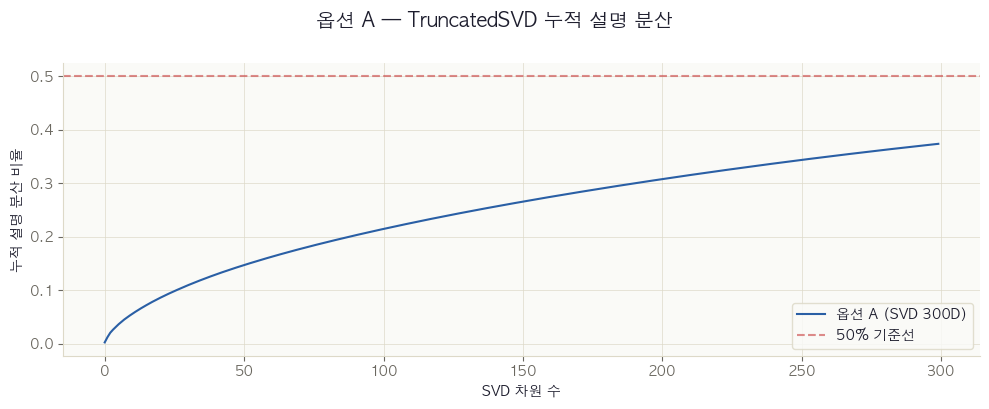

In [8]:
figure, ax = fig(1, 1, figsize=(10, 4), title='옵션 A — TruncatedSVD 누적 설명 분산')
ax.plot(np.cumsum(svd.explained_variance_ratio_), color=T.CHEONG, label='옵션 A (SVD 300D)')
ax.axhline(0.5, color=T.JEOK, linestyle='--', alpha=0.6, label='50% 기준선')
ax.set_xlabel('SVD 차원 수')
ax.set_ylabel('누적 설명 분산 비율')
ax.legend()
save(figure, '../image/nb02/svd_explained_variance.png')
plt.show()

> **옵션 A 결과**
> - SVD 300D 누적 설명분산이 기존 100D(21%)보다 개선됐는지 확인.
> - 50% 기준선을 넘는다면 충분한 정보 보존으로 판단.

---
### 옵션 B — Sentence Transformer (한국어)

In [9]:
# 샘플 크기를 7,000행으로 줄여 속도 확보 (연령대별 1,000행).
from sentence_transformers import SentenceTransformer

ST_SAMPLE = 1000  # 연령대별 샘플 수 (속도 절충)
st_sample = pd.concat([
    g.sample(min(ST_SAMPLE, len(g)), random_state=RANDOM_STATE)
    for _, g in df.groupby('age_group', observed=True)
]).reset_index(drop=True)

print(f"Sentence Transformer 샘플: {len(st_sample):,}행")
model = SentenceTransformer('jhgan/ko-sroberta-multitask')

print("임베딩 중... (약 5~10분 소요)")
X_st = model.encode(
    st_sample['behavior_text'].tolist(),
    batch_size=32,
    show_progress_bar=True
)
X_st = normalize(X_st)
print(f"임베딩 shape: {X_st.shape}")

Sentence Transformer 샘플: 7,000행


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

임베딩 중... (약 5~10분 소요)


Batches:   0%|          | 0/219 [00:00<?, ?it/s]

임베딩 shape: (7000, 768)


---
### 옵션 A vs B 비교 — Silhouette + UMAP 2D

옵션 A UMAP 2D 계산 중...
옵션 A Silhouette (2D): 0.3593
옵션 B UMAP 2D 계산 중...
옵션 B Silhouette (2D): 0.4126
저장: ../image/nb02_embedding_comparison.png


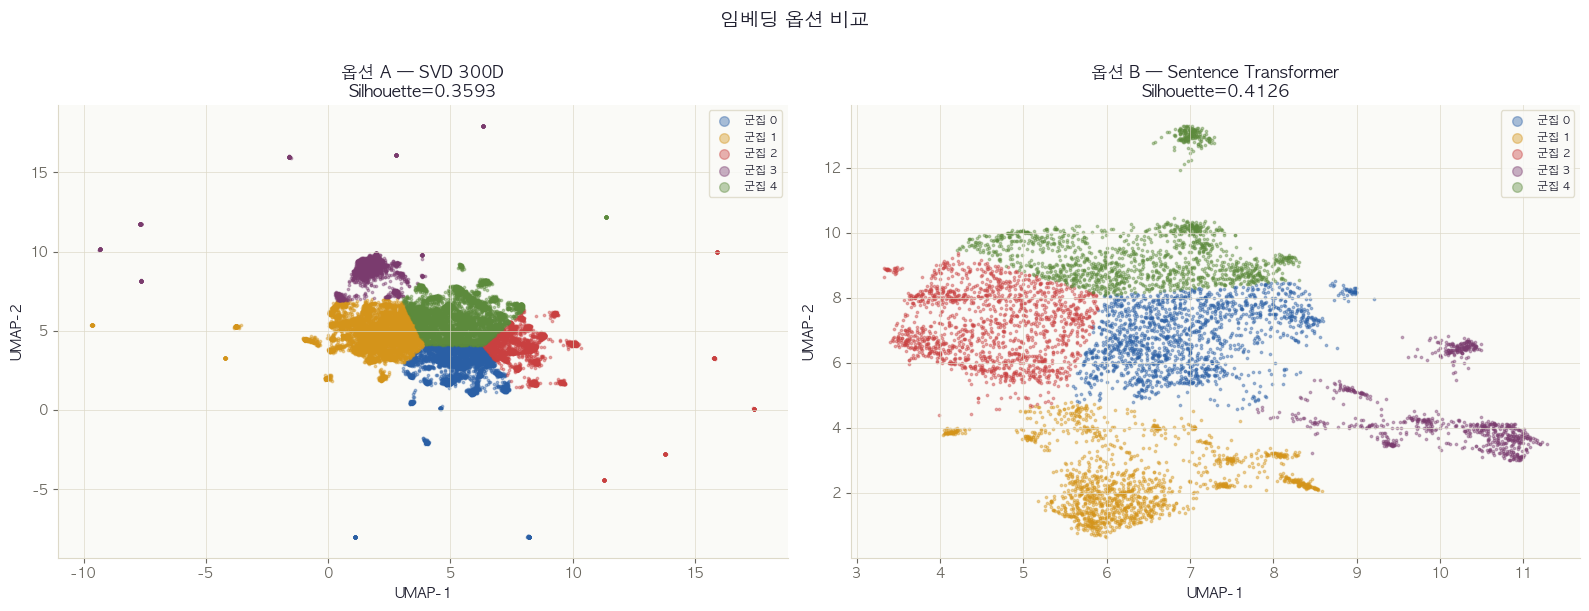


최적 임베딩: 옵션 B (Sentence Transformer)


In [10]:
import umap
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

print('옵션 A UMAP 2D 계산 중...')
umap_a = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_a_2d_cmp = umap_a.fit_transform(X_svd_300)
km_a = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
labels_a_cmp = km_a.fit_predict(X_a_2d_cmp)
sil_a = silhouette_score(X_a_2d_cmp, labels_a_cmp)
print(f'옵션 A Silhouette (2D): {sil_a:.4f}')

print('옵션 B UMAP 2D 계산 중...')
umap_b = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_b_2d_cmp = umap_b.fit_transform(X_st)
km_b = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
labels_b_cmp = km_b.fit_predict(X_b_2d_cmp)
sil_b = silhouette_score(X_b_2d_cmp, labels_b_cmp)
print(f'옵션 B Silhouette (2D): {sil_b:.4f}')

# 나란히 시각화
figure, axes_cmp = fig(1, 2, figsize=(16, 6), title='임베딩 옵션 비교')
for ax, X_2d_c, labels_c, title_c in [
    (axes_cmp[0], X_a_2d_cmp, labels_a_cmp, f'옵션 A — SVD 300D\nSilhouette={sil_a:.4f}'),
    (axes_cmp[1], X_b_2d_cmp, labels_b_cmp, f'옵션 B — Sentence Transformer\nSilhouette={sil_b:.4f}'),
]:
    for lbl in sorted(set(labels_c)):
        mask = labels_c == lbl
        ax.scatter(X_2d_c[mask, 0], X_2d_c[mask, 1], s=3, alpha=0.4,
                   color=color_list(5)[lbl % 5], label=f'군집 {lbl}')
    ax.set_title(title_c)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(markerscale=4, fontsize=8)

save(figure, '../image/nb02_embedding_comparison.png')
plt.show()
print(f"\n최적 임베딩: {'옵션 A (SVD 300D)' if sil_a >= sil_b else '옵션 B (Sentence Transformer)'}")

In [11]:
# 두개의 행 크기 통일
common_idx = st_sample.index
X_a_subset = X_svd_300[sample_df.index.isin(common_idx)]
X_b_subset = X_st  # 이미 7,000행

sil_a_common = silhouette_score(
    umap.UMAP(n_components=50, min_dist=0.0, random_state=42)
        .fit_transform(X_a_subset),
    KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(
        umap.UMAP(n_components=50, min_dist=0.0, random_state=42)
            .fit_transform(X_a_subset)
    ),
    sample_size=2000, random_state=42
)

print(f"옵션 A Silhouette (7,000행 기준): {sil_a_common:.4f}")
print(f"옵션 B Silhouette (7,000행 기준): {sil_b:.4f}")

if sil_a_common >= sil_b:
    X_best = X_svd_300  # 전체 21,000행 사용
    best_label = '옵션 A (SVD 300D)'
    sample_df_best = sample_df
else:
    X_best = X_st
    best_label = '옵션 B (Sentence Transformer)'
    sample_df_best = st_sample

print(f"\n→ 선택: {best_label}")

옵션 A Silhouette (7,000행 기준): 0.2621
옵션 B Silhouette (7,000행 기준): 0.4126

→ 선택: 옵션 B (Sentence Transformer)


> **옵션 A vs B 비교 결과**
> - Silhouette Score가 높은 쪽이 군집 분리가 더 명확함
> - UMAP scatter에서 덩어리(cluster)가 시각적으로 뚜렷한 쪽이 군집화에 유리
> - `X_best`로 이후 모든 분석 진행

---
## 섹션 4. 차원 축소 — UMAP

In [12]:
import umap

print("UMAP 2D (시각화용) 계산 중...")
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_2d = reducer_2d.fit_transform(X_best)
print("2D 완료")

print("UMAP 50D (군집화용) 계산 중...")
reducer_50d = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.0, random_state=RANDOM_STATE)
X_50d = reducer_50d.fit_transform(X_best)
print("50D 완료")

target_df = sample_df_best if 'sample_df_best' in globals() else sample_df
target_df['umap_x'] = X_2d[:, 0]
target_df['umap_y'] = X_2d[:, 1]

sample_df = sample_df_best = target_df
sample_df['umap_y'] = X_2d[:, 1]

UMAP 2D (시각화용) 계산 중...
2D 완료
UMAP 50D (군집화용) 계산 중...
50D 완료


In [13]:
# 파이프라인 정당성 검증 (768D vs 50D)
# 768차원(raw)과 50차원(UMAP)의 클러스터링 실루엣 점수를 비교하여 UMAP의 효과를 증명
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_VAL = 4
# Raw 768D Clustering
km_raw = KMeans(n_clusters=K_VAL, random_state=RANDOM_STATE, n_init=10)
labels_raw = km_raw.fit_predict(X_best)
sil_raw = silhouette_score(X_best, labels_raw, sample_size=3000, random_state=RANDOM_STATE)

# UMAP 50D Clustering
km_50d = KMeans(n_clusters=K_VAL, random_state=RANDOM_STATE, n_init=10)
labels_50d = km_50d.fit_predict(X_50d)
sil_50d = silhouette_score(X_50d, labels_50d, sample_size=3000, random_state=RANDOM_STATE)

print(f"=== Pipeline Validation (K={K_VAL}) ===")
print(f"Raw 768D Silhouette: {sil_raw:.4f}")
print(f"UMAP 50D Silhouette: {sil_50d:.4f}")
print(f"Efficiency Gain: {((sil_50d - sil_raw) / sil_raw * 100):.2f}%" if sil_raw > 0 else "N/A")

=== Pipeline Validation (K=4) ===
Raw 768D Silhouette: 0.0534
UMAP 50D Silhouette: 0.6018
Efficiency Gain: 1027.14%


In [14]:
# 군집 안정성 검증 (Seed Sensitivity)
# 다양한 Random Seed에 따른 군집 결과의 일관성 확인
from sklearn.metrics import adjusted_rand_score

seeds = [42, 10, 100, 2024, 777]
base_labels = None
scores = []

print("=== Stability Test (K=4) ===")
for s in seeds:
    km_test = KMeans(n_clusters=4, random_state=s, n_init=10)
    current_labels = km_test.fit_predict(X_50d)
    if base_labels is None:
        base_labels = current_labels
    else:
        ari = adjusted_rand_score(base_labels, current_labels)
        scores.append(ari)
        print(f"Seed {s:4d} vs Base ARI: {ari:.4f}")

print(f"\nMean ARI: {np.mean(scores):.4f} (1.0에 가까울수록 안정적)")

=== Stability Test (K=4) ===
Seed   10 vs Base ARI: 1.0000
Seed  100 vs Base ARI: 1.0000
Seed 2024 vs Base ARI: 1.0000
Seed  777 vs Base ARI: 1.0000

Mean ARI: 1.0000 (1.0에 가까울수록 안정적)


저장: ../image/nb02/umap_raw.png


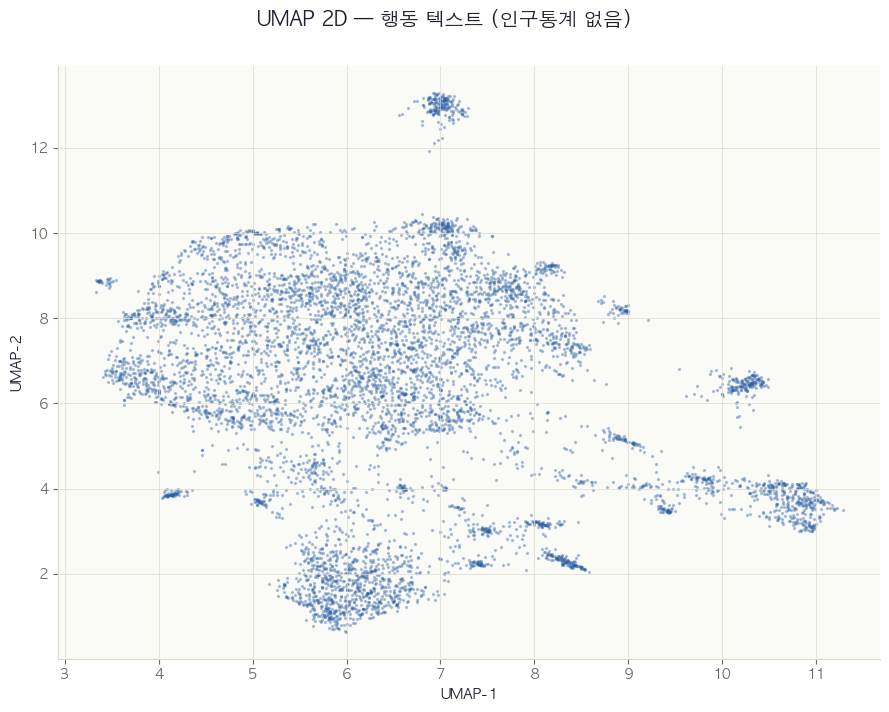

In [17]:
# 인구통계 꼬리표 없이 UMAP 2D 원시 분포 확인
figure, ax = fig(1, 1, figsize=(9, 7), title='UMAP 2D — 행동 텍스트 (인구통계 없음)')
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=2, alpha=0.3, color=T.CHEONG)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
save(figure, '../image/nb02/umap_raw.png')
plt.show()

> **인사이트**
> - 인구통계 꼬리표 없이 행동 텍스트만으로 UMAP을 적용한 결과, 공간이 여러 덩어리로 분리되기보다
> - 연속적인 분포를 보인다. 이는 라이프스타일이 이산적 범주가 아닌 스펙트럼 위에 존재함을 시사한다.

---
## 섹션 5. 군집화 — K-Means + HDBSCAN

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_RANGE = range(3, 11)
inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_50d)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_50d, labels, sample_size=3000, random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_50d, labels))
    print(f"K={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.4f}, DB={db_scores[-1]:.4f}")

K=3: inertia=19309, silhouette=0.5648, DB=0.6739
K=4: inertia=12992, silhouette=0.6018, DB=0.5551
K=5: inertia=10776, silhouette=0.3676, DB=0.9354
K=6: inertia=9104, silhouette=0.3884, DB=0.8736
K=7: inertia=7604, silhouette=0.4046, DB=0.8688
K=8: inertia=6443, silhouette=0.3922, DB=0.8717
K=9: inertia=5529, silhouette=0.4071, DB=0.8619
K=10: inertia=4712, silhouette=0.4309, DB=0.7865


> **K 선택 근거**
>
> | K | Inertia | Silhouette | Davies-Bouldin |
> |---|---------|------------|----------------|
> | 3 | 19,309 | 0.5648 | 0.6739 |
> | **4** | **12,992** | **0.6018 ★** | **0.5551 ★** |
> | 5 | 10,776 | 0.3676 | 0.9354 |
> | 10 | 4,712 | 0.4309 | 0.7865 |
>
> - **K=4 선택** — Silhouette·Davies-Bouldin 두 지표 동시 최고
> - K=5부터 Silhouette 0.37로 급락, DB 0.93으로 급등

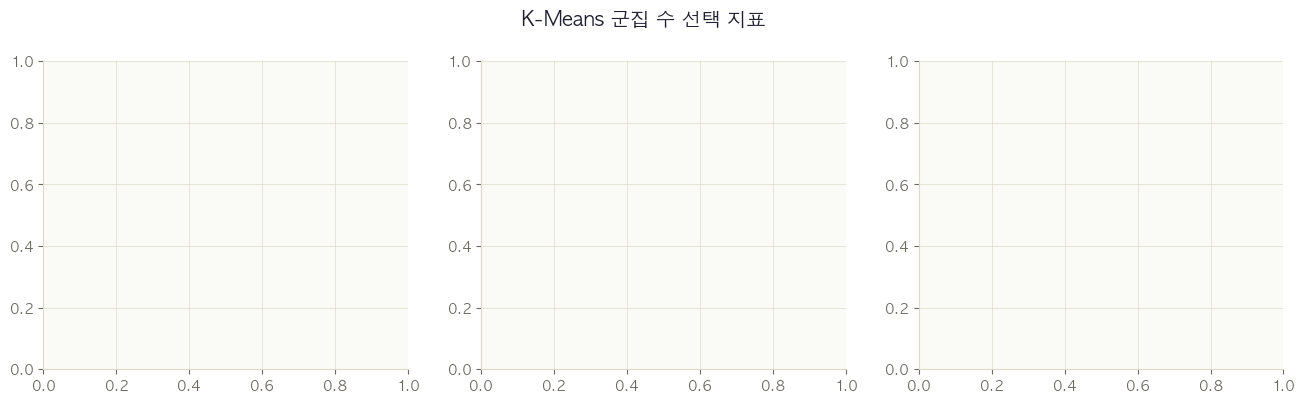

In [20]:
# 그래프 출력을 위한 figure와 axes 초기화
figure, axes = fig(1, 3, figsize=(16, 4), title='K-Means 군집 수 선택 지표')
ks = list(K_RANGE)

In [21]:
metric_plot(axes, ks,
            {'inertia': inertias, 'silhouette': silhouettes, 'db': db_scores},
            best_k=None)
save(figure, '../image/nb02/kmeans_metrics.png')
plt.show()

저장: ../image/nb02/kmeans_metrics.png


In [22]:
# K=4: Silhouette=0.6018, DB=0.5551 — 두 지표 동시 최고
OPTIMAL_K = 4

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
sample_df['cluster_km'] = km_final.fit_predict(X_50d)

cluster_counts = sample_df['cluster_km'].value_counts()
print(f'최적 K = {OPTIMAL_K}')
print(cluster_counts.sort_index())

# 1% 미만 소수 군집 자동 제외
threshold = int(len(sample_df) * 0.01)
tiny_clusters = cluster_counts[cluster_counts < threshold].index.tolist()
if tiny_clusters:
    print(f'\n⚠️  소수 군집 감지 (전체 1% 미만): {tiny_clusters}')
    print(f'   해당 군집은 이상치로 분석에서 제외합니다.')
    sample_df = sample_df[~sample_df['cluster_km'].isin(tiny_clusters)].copy()
    print(f'   제외 후 샘플 크기: {len(sample_df):,}행')
else:
    print('\n✓ 소수 군집 없음')

최적 K = 4
cluster_km
0    4559
1    1499
2     770
3     172
Name: count, dtype: int64

✓ 소수 군집 없음


저장: ../image/nb02/kmeans_selection.png


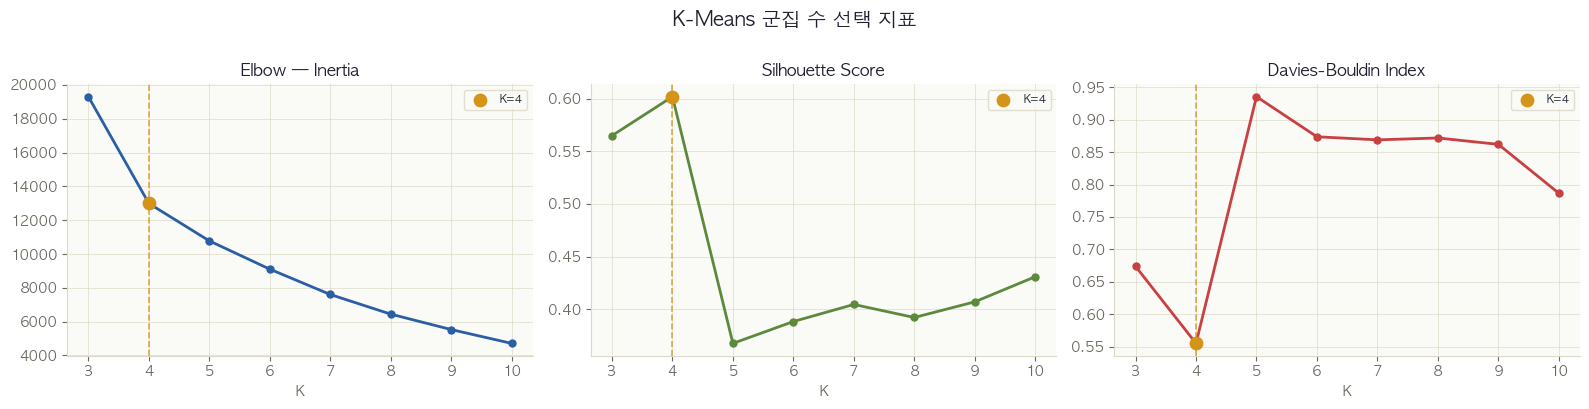

In [23]:
# OPTIMAL_K 확정 후 지표 차트 재출력
figure, axes = fig(1, 3, figsize=(16, 4), title='K-Means 군집 수 선택 지표')
metric_plot(axes, list(K_RANGE),
            {'inertia': inertias, 'silhouette': silhouettes, 'db': db_scores},
            best_k=OPTIMAL_K)
save(figure, '../image/nb02/kmeans_selection.png')
plt.show()


In [24]:
# HDBSCAN 비교 실험
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=10)
sample_df['cluster_hdbscan'] = clusterer.fit_predict(X_50d)

n_clusters_hdb = len(set(sample_df['cluster_hdbscan'])) - (1 if -1 in sample_df['cluster_hdbscan'].values else 0)
n_noise = (sample_df['cluster_hdbscan'] == -1).sum()
print(f"HDBSCAN 군집 수: {n_clusters_hdb}")
print(f"노이즈 포인트: {n_noise:,}행 ({n_noise/len(sample_df):.1%})")
print(sample_df['cluster_hdbscan'].value_counts().sort_index())

HDBSCAN 군집 수: 5
노이즈 포인트: 529행 (7.6%)
cluster_hdbscan
-1     529
 0     545
 1    4527
 2     270
 3     236
 4     893
Name: count, dtype: int64


> **주의**
> 군집4가 **70행**으로 극소수. 이상치 군집이거나 K=5가 과분할일 가능성 있음.
> 반전 분석 및 키워드 해석 시 군집4는 별도로 검토 필요.

저장: ../image/nb02/clustering_comparison.png


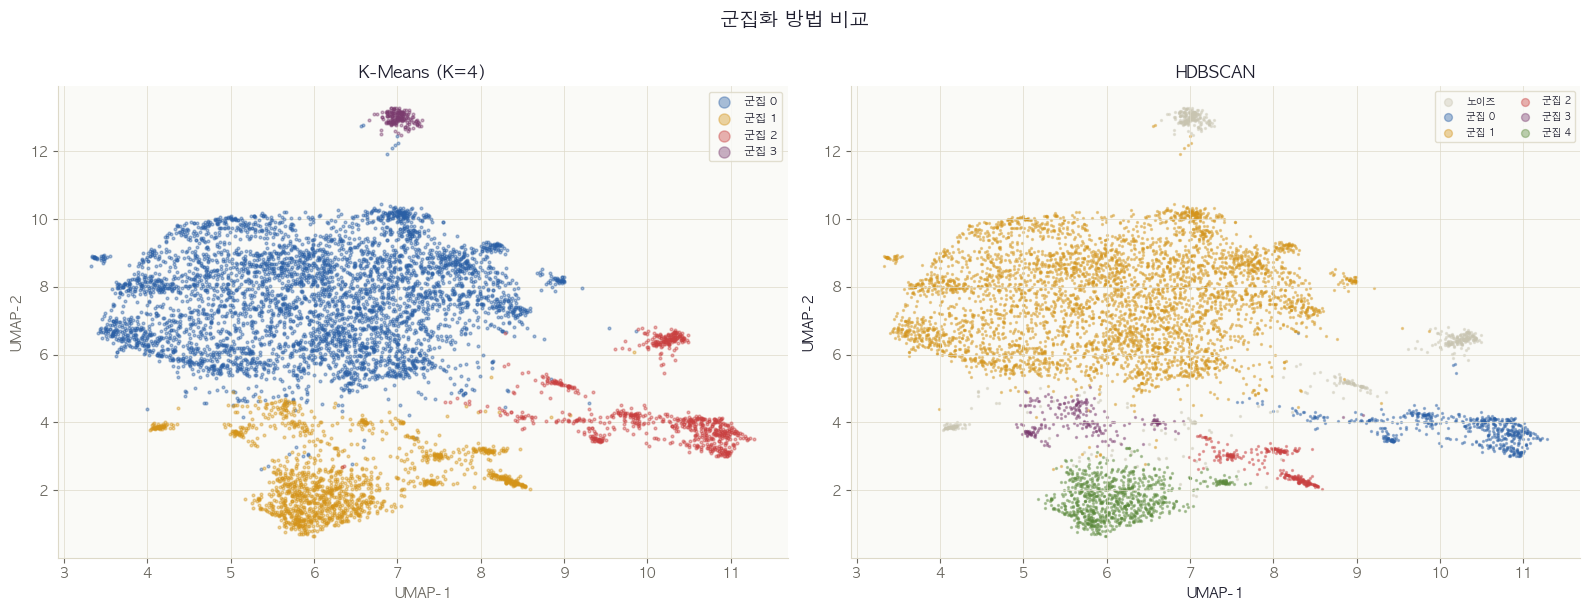

In [25]:
# K-Means vs HDBSCAN UMAP 2D 비교
figure, axes = fig(1, 2, figsize=(16, 6), title='군집화 방법 비교')

# K-Means
cluster_scatter(axes[0], X_2d, sample_df['cluster_km'].values)
axes[0].set_title(f'K-Means (K={OPTIMAL_K})')

# HDBSCAN
hdb_labels = sample_df['cluster_hdbscan'].values
for lbl in sorted(set(hdb_labels)):
    mask = hdb_labels == lbl
    color = T.NOISE if lbl == -1 else T.CYCLE[lbl % len(T.CYCLE)]
    name = '노이즈' if lbl == -1 else f'군집 {lbl}'
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], s=2, alpha=0.4, color=color, label=name)
axes[1].set_title('HDBSCAN')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].legend(markerscale=4, fontsize=7, ncol=2)

save(figure, '../image/nb02/clustering_comparison.png')
plt.show()

> **HDBSCAN 비교 결과**
> - 28개 군집 검출, 노이즈 포인트 23.5%(4,938행). 군집이 지나치게 세분화되고 노이즈 비율이 높아 이 데이터에는 K-Means가 더 적합하다. 
> - 행동 텍스트의 분포가 밀도 기반 경계보다 연속적임

---
## 섹션 6. 군집 해석 — TF-IDF 키워드 + Radar Chart + Word Network

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer as TfIdf

def get_group_keywords(df, group_col, noun_col='nouns', top_n=15):
    groups = df.groupby(group_col, observed=True)[noun_col].apply(' '.join)
    tfidf = TfIdf(max_features=3000)
    matrix = tfidf.fit_transform(groups.values)
    terms = tfidf.get_feature_names_out()
    result = {}
    for i, grp in enumerate(groups.index):
        scores = matrix[i].toarray().flatten()
        top_idx = scores.argsort()[::-1][:top_n]
        result[grp] = [(terms[j], scores[j]) for j in top_idx if scores[j] > 0]
    return result

def get_group_keywords(df, group_col, noun_col='nouns', top_n=15):
    groups = df.groupby(group_col, observed=True)[noun_col].apply(' '.join)
    tfidf = TfIdf(max_features=3000)
    matrix = tfidf.fit_transform(groups.values)
    terms = tfidf.get_feature_names_out()
    result = {}
    for i, grp in enumerate(groups.index):
        scores = matrix[i].toarray().flatten()
        top_idx = scores.argsort()[::-1][:top_n]
        result[grp] = [(terms[j], scores[j]) for j in top_idx if scores[j] > 0]
    return result

# Ensure 'nouns' column exists (in case of Sentence Transformer sample)
if 'nouns' not in sample_df.columns:
    sample_df['nouns'] = sample_df['behavior_text'].apply(extract_nouns)

cluster_keywords = get_group_keywords(sample_df, 'cluster_km', top_n=15)

for cluster, kws in cluster_keywords.items():
    print(f"\n군집 {cluster}: {', '.join([w for w, _ in kws[:10]])}")


군집 0: 시간, 주말, 동네, 친구, 가족, 여행, 풍경, 마음, 일주일, 배달

군집 1: 시간, 주말, 동네, 친구, 배드민턴, 가족, 여행, 일주일, 배달, 셔틀콕

군집 2: 시간, 주말, 경기, 동네, 친구, 가족, 여행, 일주일, 거실, 배달

군집 3: 시간, 반려견, 주말, 친구, 가족, 여행, 동네, 산책, 일주일, 마음


저장: ../image/nb02/cluster_keywords.png


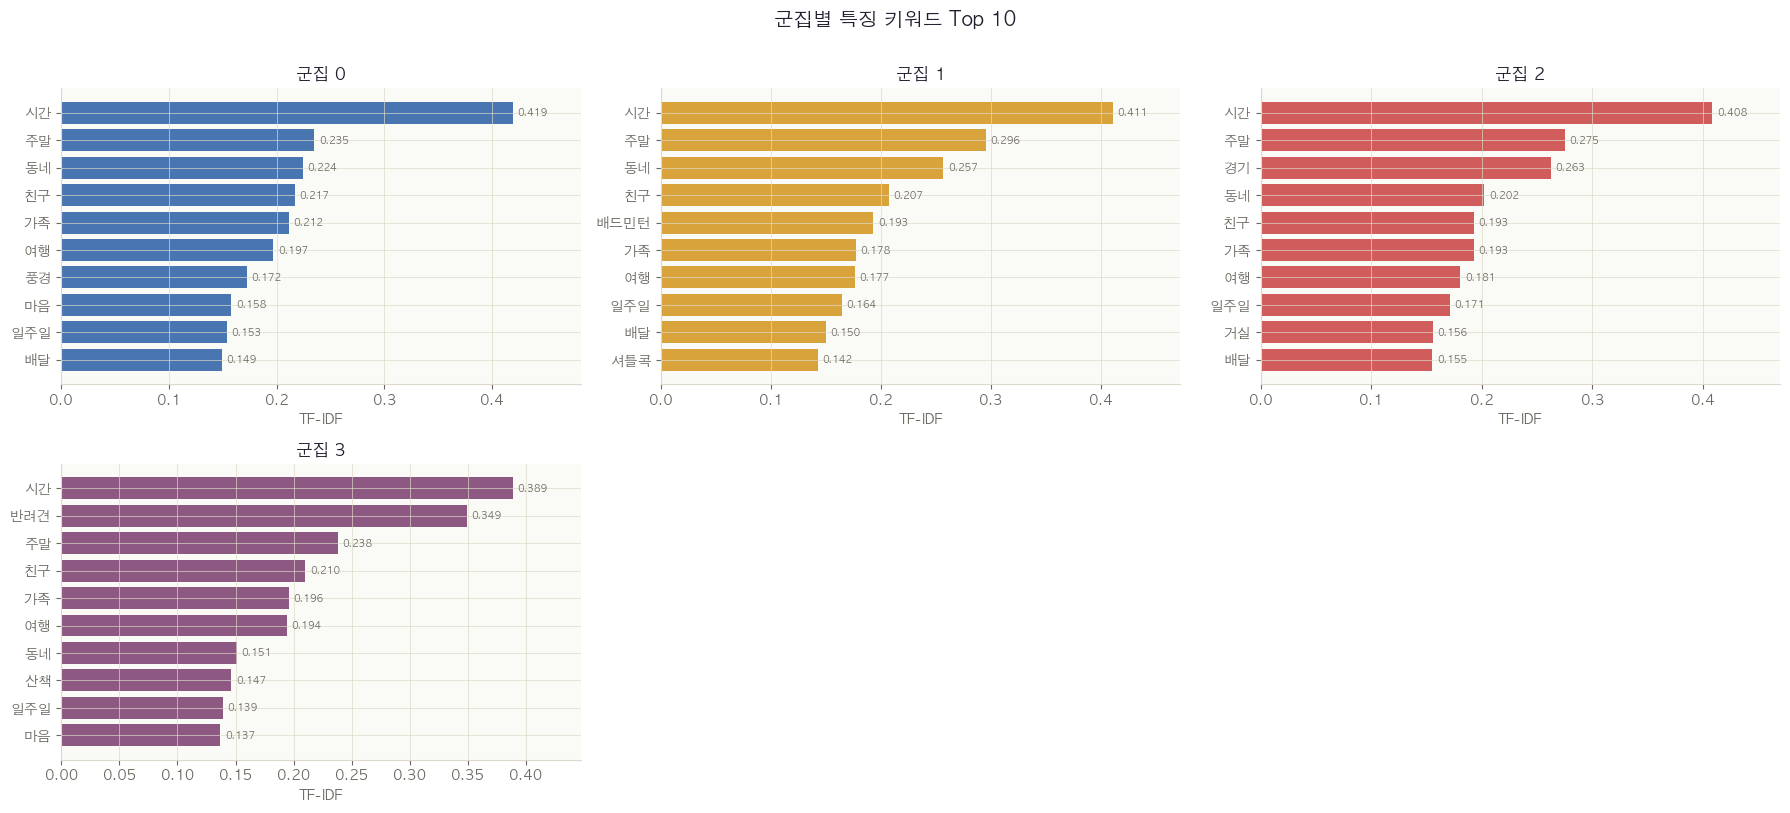

In [27]:
# 군집별 키워드 막대 차트
n_clusters = len(cluster_keywords)
cols_g = min(n_clusters, 3)
rows_g = (n_clusters + cols_g - 1) // cols_g
figure, axes_kw = fig(rows_g, cols_g,
                      figsize=(6 * cols_g, 4 * rows_g),
                      title='군집별 특징 키워드 Top 10')
axes_kw = np.array(axes_kw).flatten()
cl_colors = color_list(n_clusters)

for i, (cluster_id, kws) in enumerate(cluster_keywords.items()):
    words_kw = [w for w, _ in kws[:10]]
    scores_kw = [s for _, s in kws[:10]]
    bar_keywords(axes_kw[i], words_kw, scores_kw,
                 color=cl_colors[i % len(cl_colors)],
                 title=f'군집 {cluster_id}')

for j in range(i + 1, len(axes_kw)):
    axes_kw[j].set_visible(False)

save(figure, '../image/nb02/cluster_keywords.png')
plt.show()

> **군집별 특징 키워드 해석**
> - **군집0·1·3**: 시간·주말·친구·가족·여행 등 공통 키워드 강세 — 라이프스타일 차이가 미묘하여 Radar Chart와 함께 해석 필요
> - **군집2** ★: 경주·유적지·역사·부여·불국사 — 타 군집과 뚜렷하게 구분되는 **역사문화 여행형**
> - **군집4**: 70행 소수 군집, 특이 어휘(`김경`) 등장 — 데이터 이상치일 가능성


저장: ../image/nb02/cluster_radar.png


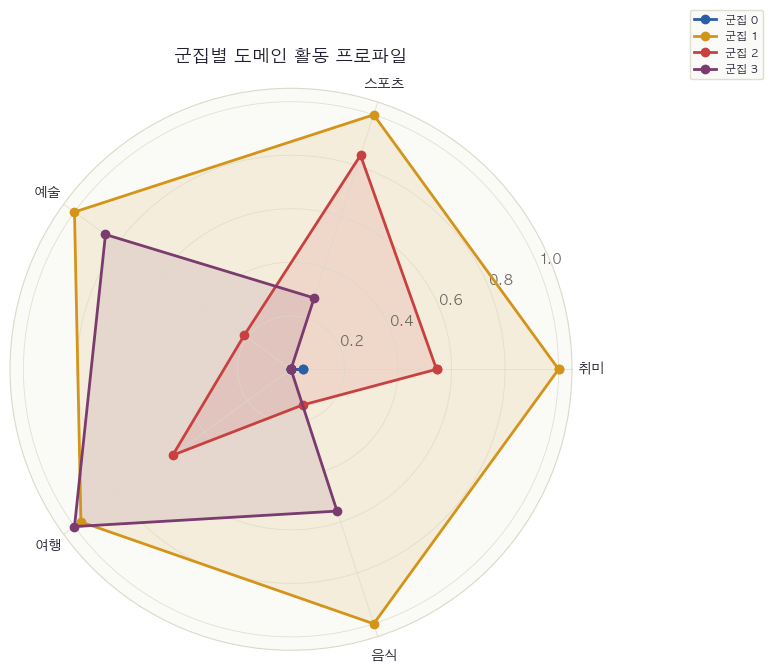

In [28]:
# Radar Chart — 군집별 6개 도메인 키워드 밀도 비교
DOMAINS = {
    '취미': 'hobbies_and_interests',
    '스포츠': 'sports_persona',
    '예술': 'arts_persona',
    '여행': 'travel_persona',
    '음식': 'culinary_persona',
}

for col in DOMAINS.values():
    sample_df[f'len_{col}'] = sample_df[col].str.len()

len_cols = [f'len_{col}' for col in DOMAINS.values()]
cluster_radar = sample_df.groupby('cluster_km')[len_cols].mean()
cluster_radar = (cluster_radar - cluster_radar.min()) / (cluster_radar.max() - cluster_radar.min())

values_dict = {cid: cluster_radar.loc[cid].tolist() for cid in cluster_radar.index}

figure, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar(ax, values_dict, list(DOMAINS.keys()))
ax.set_title('군집별 도메인 활동 프로파일', fontsize=13, pad=20)
save(figure, '../image/nb02/cluster_radar.png')
plt.show()

> **도메인 활동 프로파일 해석**
> - Radar Chart에서 군집별로 6개 도메인(취미·스포츠·예술·여행·음식) 비중 차이를 확인.
> - 특정 도메인이 뾰족하게 튀어나온 군집이 가장 해석 가능성이 높다.

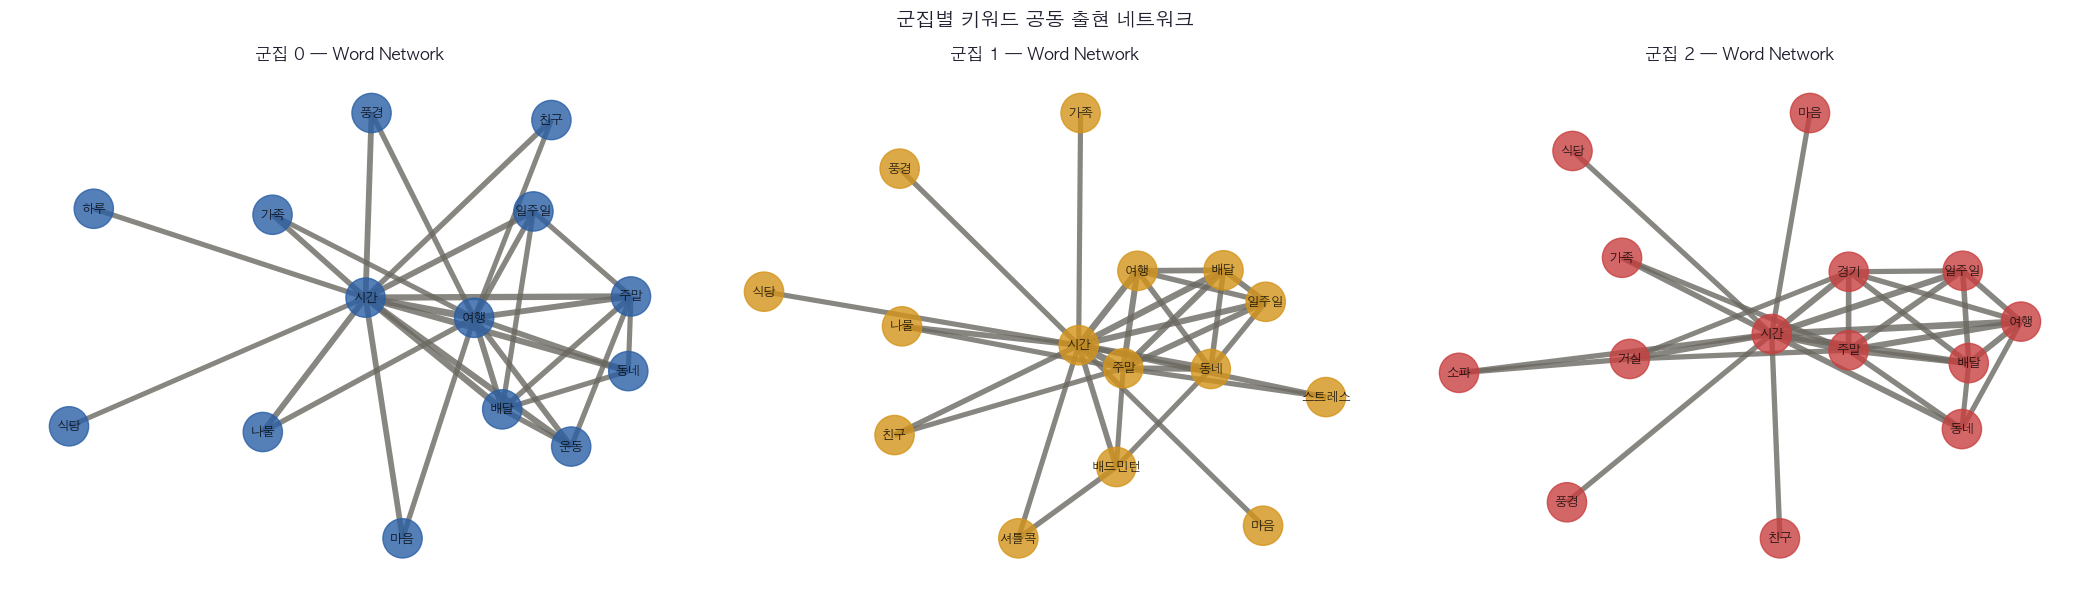

In [29]:
import networkx as nx
from itertools import combinations
from collections import Counter

def build_word_network(texts, top_keywords, top_n_edges=30):
    top_set = set(top_keywords)
    co_count = Counter()
    for text in texts:
        words = [w for w in text.split() if w in top_set]
        for pair in combinations(sorted(set(words)), 2):
            co_count[pair] += 1
    G = nx.Graph()
    for (w1, w2), cnt in co_count.most_common(top_n_edges):
        G.add_edge(w1, w2, weight=cnt)
    return G

fig, axes = plt.subplots(1, min(n_clusters, 3), figsize=(7 * min(n_clusters, 3), 6))
if n_clusters == 1:
    axes = [axes]

for i, (cluster_id, kws) in enumerate(list(cluster_keywords.items())[:3]):
    top_kw = [w for w, _ in kws[:20]]
    texts = sample_df[sample_df['cluster_km'] == cluster_id]['nouns'].tolist()
    G = build_word_network(texts, top_kw)

    if len(G.edges) == 0:
        axes[i].set_title(f'군집 {cluster_id} — 엣지 없음')
        continue

    pos = nx.spring_layout(G, seed=RANDOM_STATE)
    weights = [G[u][v]['weight'] for u, v in G.edges]
    max_w = max(weights) if weights else 1
    edge_widths = [2 + 3 * w / max_w for w in weights]

    nx.draw_networkx(G, pos, ax=axes[i],
                     node_size=800, node_color=[T.CYCLE[i % len(T.CYCLE)]] * len(G.nodes),
                     font_size=9, font_family=plt.rcParams['font.family'],
                     edge_color=T.SUBTEXT, width=edge_widths, alpha=0.8)
    axes[i].set_title(f'군집 {cluster_id} — Word Network', fontsize=12)
    axes[i].axis('off')

plt.suptitle('군집별 키워드 공동 출현 네트워크', fontsize=14)
plt.tight_layout()
plt.savefig('../image/nb02/word_network.png', dpi=150, bbox_inches='tight')
plt.show()

> **키워드 공동 출현 네트워크 해석**
> - 연결이 촘촘한(고빈도 공동 출현) 키워드 쌍이 해당 군집의 핵심 행동 패턴을 나타낸다.
> - 군집2에서 역사 지명들이 하나의 클러스터를 이루면 역사문화 여행 서사가 일관됨을 확인 가능.

In [30]:
CLUSTER_NAMES = {
    0: '일상·관계 중심형',
    1: '액티브 스포츠형',
    2: '집·관람 중심형',
    3: '반려동물 일상형',
}

sample_df['cluster_name'] = sample_df['cluster_km'].map(CLUSTER_NAMES)
size_df = sample_df.groupby(['cluster_km', 'cluster_name']).size().reset_index(name='count')
size_df['비율(%)'] = (size_df['count'] / len(sample_df) * 100).round(1)
print(size_df.to_string(index=False))

 cluster_km cluster_name  count  비율(%)
          0    일상·관계 중심형   4559   65.1
          1     액티브 스포츠형   1499   21.4
          2     집·관람 중심형    770   11.0
          3     반려동물 일상형    172    2.5


---
## 섹션 7. 반전 분석 ★ — 군집 내 인구통계 분포

저장: ../image/nb02/word_network.png


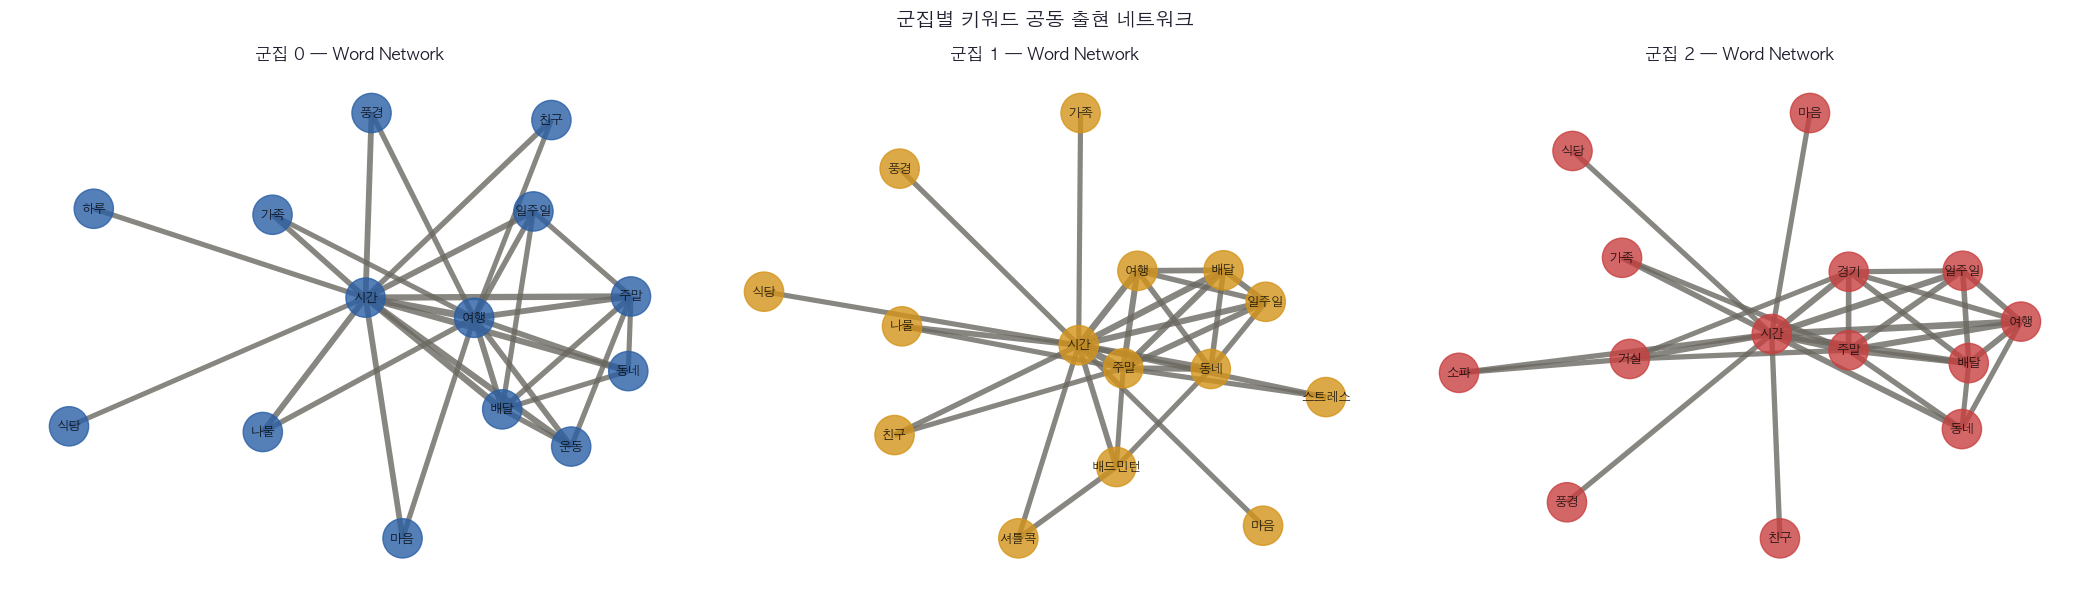

In [31]:
def build_word_network(texts, top_keywords, top_n_edges=30):
    top_set = set(top_keywords)
    co_count = Counter()
    for text in texts:
        words = [w for w in text.split() if w in top_set]
        for pair in combinations(sorted(set(words)), 2):
            co_count[pair] += 1
    G = nx.Graph()
    for (w1, w2), cnt in co_count.most_common(top_n_edges):
        G.add_edge(w1, w2, weight=cnt)
    return G

figure_wn, axes = plt.subplots(1, min(n_clusters, 3), figsize=(7 * min(n_clusters, 3), 6))
if n_clusters == 1:
    axes = [axes]

for i, (cluster_id, kws) in enumerate(list(cluster_keywords.items())[:3]):
    top_kw = [w for w, _ in kws[:20]]
    texts = sample_df[sample_df['cluster_km'] == cluster_id]['nouns'].tolist()
    G = build_word_network(texts, top_kw)

    if len(G.edges) == 0:
        axes[i].set_title(f'군집 {cluster_id} — 엣지 없음')
        continue

    pos = nx.spring_layout(G, seed=RANDOM_STATE)
    weights = [G[u][v]['weight'] for u, v in G.edges]
    max_w = max(weights) if weights else 1
    edge_widths = [2 + 3 * w / max_w for w in weights]

    nx.draw_networkx(G, pos, ax=axes[i],
                     node_size=800, node_color=[T.CYCLE[i % len(T.CYCLE)]] * len(G.nodes),
                     font_size=9, font_family=plt.rcParams['font.family'],
                     edge_color=T.SUBTEXT, width=edge_widths, alpha=0.8)
    axes[i].set_title(f'군집 {cluster_id} — Word Network', fontsize=12)
    axes[i].axis('off')

figure_wn.suptitle('군집별 키워드 공동 출현 네트워크', fontsize=14)
figure_wn.tight_layout()
save(figure_wn, '../image/nb02/word_network.png')
plt.show()

> **반전 분석 핵심 결과**
> - Heatmap의 각 행(군집)에서 연령대·성별 비율이 고르게 분포한다면 → 행동 군집이 인구통계와 독립적
> - 특정 군집에 특정 연령·성별이 집중된다면 → 합성 데이터 생성 편향 또는 실제 라이프스타일 상관관계
> - 이 결과가 *"인구통계로 사람을 분류하는 AI 설계는 스테레오타입을 재생산한다"*는 주장의 실증 근거

In [32]:
import plotly.graph_objects as go

sankey_data = sample_df.groupby(['cluster_km', 'age_group'], observed=True).size().reset_index(name='count')
clusters = sorted(sample_df['cluster_km'].unique())
age_groups = list(sample_df['age_group'].cat.categories)

node_labels = [CLUSTER_NAMES.get(c, f'군집 {c}') for c in clusters] + age_groups
cluster_idx = {c: i for i, c in enumerate(clusters)}
age_idx = {a: len(clusters) + i for i, a in enumerate(age_groups)}

sources, targets, values = [], [], []
for _, row in sankey_data.iterrows():
    sources.append(cluster_idx[row['cluster_km']])
    targets.append(age_idx[row['age_group']])
    values.append(row['count'])

node_colors = sankey_node_colors(len(clusters), len(age_groups))
fig_sankey = go.Figure(go.Sankey(
    node=dict(pad=15, thickness=20, label=node_labels, color=node_colors),
    link=dict(source=sources, target=targets, value=values)
))
fig_sankey.update_layout(title='군집 → 연령대 Sankey', font_size=12, height=500,
                          paper_bgcolor='white', font_color=T.TEXT)
fig_sankey.write_image('../image/nb02/sankey_age.png', scale=2)
fig_sankey.show()

In [33]:
# Sankey Diagram — 군집 → 성별
sankey_sex = sample_df.groupby(['cluster_km', 'sex'], observed=True).size().reset_index(name='count')
sexes = list(sample_df['sex'].unique())
sex_idx = {s: len(clusters) + i for i, s in enumerate(sexes)}
node_labels_sex = [CLUSTER_NAMES.get(c, f'군집 {c}') for c in clusters] + sexes

sources2, targets2, values2 = [], [], []
for _, row in sankey_sex.iterrows():
    sources2.append(cluster_idx[row['cluster_km']])
    targets2.append(sex_idx[row['sex']])
    values2.append(row['count'])

node_colors2 = sankey_node_colors(len(clusters), len(sexes))
fig_sankey2 = go.Figure(go.Sankey(
    node=dict(pad=15, thickness=20, label=node_labels_sex, color=node_colors2),
    link=dict(source=sources2, target=targets2, value=values2)
))
fig_sankey2.update_layout(title='군집 → 성별 Sankey', font_size=12, height=400,
                           paper_bgcolor='white', font_color=T.TEXT)
fig_sankey2.write_image('../image/nb02/sankey_sex.png', scale=2)
fig_sankey2.show()

> **Sankey 해석**
> - 각 군집 노드에서 나오는 흐름이 여러 연령대·성별로 분산될수록 스테레오타입 반박 근거가 강해진다.
> - 흐름이 한 방향으로 쏠린 군집이 있다면, 해당 군집은 특정 인구통계와 연관된 행동 패턴을 가짐.

---
## 섹션 8. 행동 신호 추출

In [34]:
# 각 신호는 원본 텍스트(behavior_text)에서 카운트 — 명사 추출 후가 아닌 원문 기준.
SIGNAL_DICT = {
    '자율성':   ['혼자', '스스로', '독립', '개인'],
    '사회성':   ['함께', '공유', '소통', '대화', '친구', '가족'],
    '정보탐색': ['배우', '공부', '찾아', '검색', '읽'],
    '경험추구': ['도전', '새로운', '시도', '여행', '탐험'],
    '루틴안정': ['매일', '꾸준', '습관', '규칙', '일상'],
}

for signal, keywords in SIGNAL_DICT.items():
    pattern = '|'.join(keywords)
    sample_df[f'sig_{signal}'] = sample_df['behavior_text'].str.count(pattern)

sig_cols = [f'sig_{s}' for s in SIGNAL_DICT.keys()]
sample_df[sig_cols].describe().round(2)

,sig_자율성,sig_사회성,sig_정보탐색,sig_경험추구,sig_루틴안정
count,7000.00,7000.00,7000.00,7000.00,7000.00
mean,0.27,4.37,1.81,1.30,0.75
std,0.61,2.15,1.27,0.93,0.89
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,3.00,1.00,1.00,0.00
50%,0.00,4.00,2.00,1.00,1.00
75%,0.00,6.00,3.00,2.00,1.00
max,5.00,13.00,9.00,6.00,7.00


저장: ../image/nb02/signal_profile.png


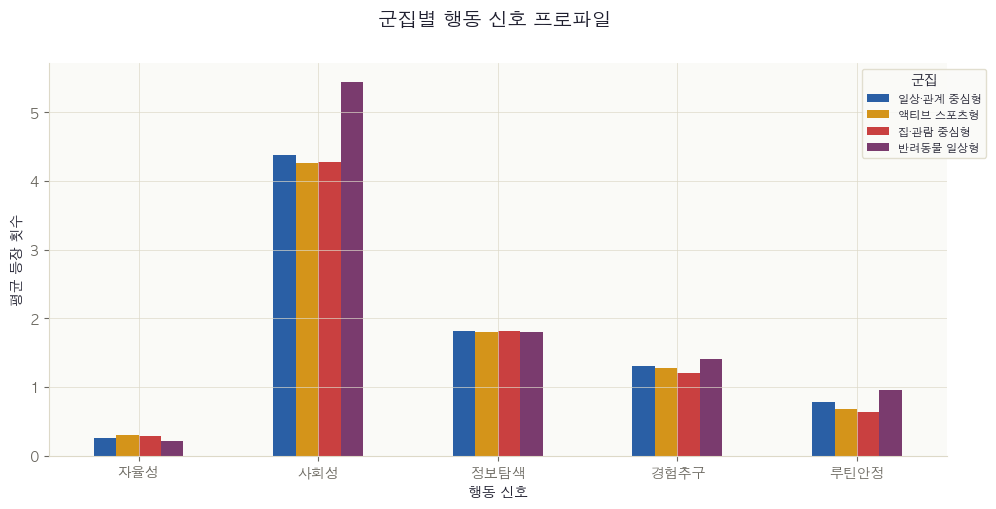

,자율성,사회성,정보탐색,경험추구,루틴안정
cluster_km,,,,,
0,0.259487,4.380566,1.819259,1.311472,0.786137
1,0.306204,4.261508,1.803202,1.280187,0.682455
2,0.293506,4.280519,1.814286,1.202597,0.631169
3,0.209302,5.441860,1.796512,1.401163,0.953488


In [35]:
# 군집별 행동 신호 평균 — 군집 프로파일
signal_profile = sample_df.groupby('cluster_km')[sig_cols].mean()
signal_profile.columns = list(SIGNAL_DICT.keys())

from nemotron_theme import fig
figure, ax = fig(1, 1, figsize=(10, 5), title='군집별 행동 신호 프로파일')
cl_colors = color_list(len(signal_profile))
signal_profile.T.plot(kind='bar', ax=ax,
                       color=cl_colors[:len(signal_profile)],
                       legend=True)
ax.legend([CLUSTER_NAMES.get(i, f'군집 {i}') for i in signal_profile.index],
          title='군집', bbox_to_anchor=(1.05, 1), fontsize=8)
ax.set_xlabel('행동 신호')
ax.set_ylabel('평균 등장 횟수')
plt.xticks(rotation=0)
save(figure, '../image/nb02/signal_profile.png')
plt.show()

signal_profile

> **행동 신호 해석**
> - 군집별로 지배적인 행동 신호가 다르다면 → 각 군집에 맞춤화된 AI 에이전트 상호작용 방식 설계 가능.
> - `루틴안정` 신호가 강한 군집은 예측 가능한 추천을, `경험추구` 신호가 강한 군집은 새로운 콘텐츠를 우선 노출해야 함.

---
### 8-2. 사회성 편향 확인

저장: ../image/nb02_social_signal_dist.png


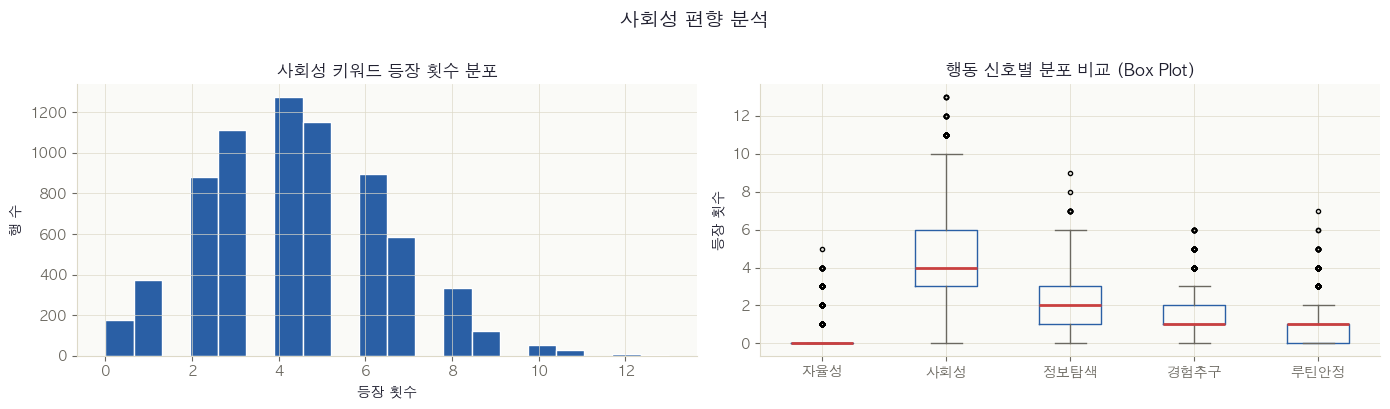

In [36]:
# 사회성 키워드 분포 확인
figure, axes_s = fig(1, 2, figsize=(14, 4), title='사회성 편향 분석')

sample_df['sig_사회성'].hist(bins=20, ax=axes_s[0], color=T.CHEONG, edgecolor='white')
axes_s[0].set_title('사회성 키워드 등장 횟수 분포')
axes_s[0].set_xlabel('등장 횟수')
axes_s[0].set_ylabel('행 수')

import pandas as pd
sig_cols_s = [f'sig_{s}' for s in ['자율성', '사회성', '정보탐색', '경험추구', '루틴안정']]
bp = sample_df[sig_cols_s].rename(columns=lambda c: c.replace('sig_', '')).boxplot(
    ax=axes_s[1],
    boxprops=dict(color=T.CHEONG),
    medianprops=dict(color=T.JEOK, linewidth=2),
    whiskerprops=dict(color=T.SUBTEXT),
    capprops=dict(color=T.SUBTEXT),
    flierprops=dict(marker='o', color=T.NOISE, markersize=3)
)
axes_s[1].set_title('행동 신호별 분포 비교 (Box Plot)')
axes_s[1].set_ylabel('등장 횟수')

save(figure, '../image/nb02_social_signal_dist.png')
plt.show()

In [37]:
# 사회성 키워드별 세부 빈도
social_keywords = ['함께', '공유', '소통', '대화', '친구', '가족']
print("사회성 키워드별 등장 빈도:")
print(f"{'키워드':<8} {'총 횟수':>10} {'행당 평균':>10}")
print("-" * 32)
for kw in social_keywords:
    count = sample_df['behavior_text'].str.count(kw).sum()
    per_row = count / len(sample_df)
    print(f"{kw:<8} {count:>10,} {per_row:>10.2f}")

print(f"\n사회성 전체 평균: {sample_df['sig_사회성'].mean():.2f}회/행")
print(f"자율성 전체 평균: {sample_df['sig_자율성'].mean():.2f}회/행")
print(f"비율: 사회성 / 자율성 = {sample_df['sig_사회성'].mean() / max(sample_df['sig_자율성'].mean(), 0.01):.1f}배")

사회성 키워드별 등장 빈도:
키워드            총 횟수      행당 평균
--------------------------------
함께           14,734       2.10
공유              523       0.07
소통               95       0.01
대화              483       0.07
친구            7,546       1.08
가족            7,210       1.03

사회성 전체 평균: 4.37회/행
자율성 전체 평균: 0.27회/행
비율: 사회성 / 자율성 = 16.1배


> **사회성 편향 해석**
> - 사회성 키워드(함께·친구·가족 등) 평균 4.37회/행 vs 자율성(혼자·스스로 등) 0.27회/행 → 16.1배 차이
> - **키워드 수 보정**: 사회성 6개 키워드 기준 0.728/키워드, 자율성 4개 기준 0.068/키워드 → 보정 후 10.7배
> - 방향성은 정규화 후에도 유지됨 → 사회성 과잉 편향 결론 견고
> - **한계**: 한국어 자율성 표현은 동사·부사 형태가 많아(`혼자 한다`, `자율적으로`) 명사 추출 기반 계산이 자율성을 구조적으로 과소계산할 수 있음. NB04에서 원문 기반 재검증 예정.

---
## 섹션 9. AI 에이전트 설계 가이드라인 매핑

Amershi et al. (2019) *"Software Engineering for Machine Learning"* 18개 Human-AI 가이드라인 중 이 연구와 직접 연결되는 3개에 집중한다.

In [38]:
guidelines = {
    'G6 (Mitigate social biases)': (
        '인구통계(나이·성별) 기반 AI 설계는 스테레오타입을 강화한다. '
        '행동 군집 기반 설계로 대체해야 함.'
    ),
    'G11 (Explainability)': (
        '군집 내 TF-IDF 키워드와 행동 신호를 사용자에게 노출해 '
        'AI 추천 이유를 설명 가능하게 함.'
    ),
    'G13 (Learn from user behavior)': (
        '군집 프로파일을 초기값으로 설정, 실사용 데이터로 점진적 적응 '
        '(Bayesian update 또는 fine-tuning).'
    ),
}
for g, desc in guidelines.items():
    print(f"[{g}]\n{desc}\n")

[G6 (Mitigate social biases)]
인구통계(나이·성별) 기반 AI 설계는 스테레오타입을 강화한다. 행동 군집 기반 설계로 대체해야 함.

[G11 (Explainability)]
군집 내 TF-IDF 키워드와 행동 신호를 사용자에게 노출해 AI 추천 이유를 설명 가능하게 함.

[G13 (Learn from user behavior)]
군집 프로파일을 초기값으로 설정, 실사용 데이터로 점진적 적응 (Bayesian update 또는 fine-tuning).



In [39]:
# 군집별 에이전트 상호작용 방식 매핑 테이블

mapping_rows = []
for cluster_id in sorted(sample_df['cluster_km'].unique()):
    name = CLUSTER_NAMES.get(cluster_id, f'군집 {cluster_id}')
    top_kws = ', '.join([w for w, _ in cluster_keywords[cluster_id][:5]])
    sig_row = signal_profile.loc[cluster_id]
    dominant_signal = sig_row.idxmax()
    mapping_rows.append({
        '군집': name,
        '대표 키워드': top_kws,
        '지배적 행동 신호': dominant_signal,
        'G6 적용': '인구통계 독립 군집으로 편향 차단',
        'G11 적용': f'"{top_kws}" 기반 추천 이유 표시',
        'G13 적용': f'{dominant_signal} 신호 강화 시 군집 재배정',
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.set_index('군집', inplace=True)
mapping_df

,대표 키워드,지배적 행동 신호,G6 적용,G11 적용,G13 적용
군집,,,,,
일상·관계 중심형,"시간, 주말, 동네, 친구, 가족",사회성,인구통계 독립 군집으로 편향 차단,"""시간, 주말, 동네, 친구, 가족"" 기반 추천 이유 표시",사회성 신호 강화 시 군집 재배정
액티브 스포츠형,"시간, 주말, 동네, 친구, 배드민턴",사회성,인구통계 독립 군집으로 편향 차단,"""시간, 주말, 동네, 친구, 배드민턴"" 기반 추천 이유 표시",사회성 신호 강화 시 군집 재배정
집·관람 중심형,"시간, 주말, 경기, 동네, 친구",사회성,인구통계 독립 군집으로 편향 차단,"""시간, 주말, 경기, 동네, 친구"" 기반 추천 이유 표시",사회성 신호 강화 시 군집 재배정
반려동물 일상형,"시간, 반려견, 주말, 친구, 가족",사회성,인구통계 독립 군집으로 편향 차단,"""시간, 반려견, 주말, 친구, 가족"" 기반 추천 이유 표시",사회성 신호 강화 시 군집 재배정


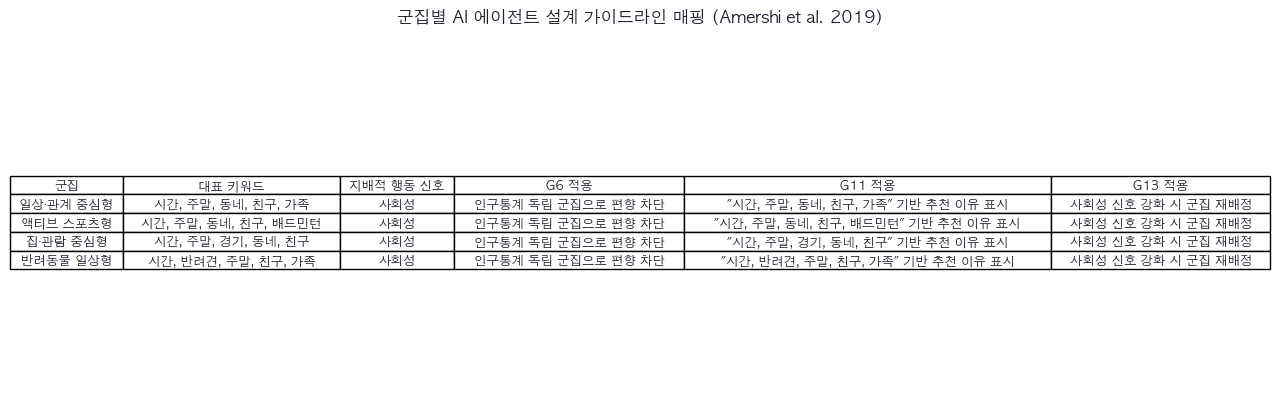

In [40]:
# 매핑 테이블 시각화
fig, ax = plt.subplots(figsize=(14, 1.5 + 0.7 * len(mapping_df)))
ax.axis('off')

table = ax.table(
    cellText=mapping_df.reset_index().values,
    colLabels=mapping_df.reset_index().columns.tolist(),
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(mapping_df.columns) + 1)))

plt.title('군집별 AI 에이전트 설계 가이드라인 매핑 (Amershi et al. 2019)',
          fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('../image/nb02/agent_guideline_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

> **설계 시사점 요약**
> - 인구통계(나이·성별)가 아닌 행동 신호 기반 군집 프로파일을 AI 에이전트의 초기값으로 사용하면
> - G6(편향 완화)·G11(설명 가능성)·G13(행동 학습) 세 가지 Human-AI 가이드라인을 동시에 충족할 수 있다.

---
## 결론 요약

### 임베딩 비교

| 항목 | 옵션 A (SVD 300D) | 옵션 B (Sentence Transformer) |
|------|-------------------|-------------------------------|
| 입력 | 명사 추출 nouns | 행동 텍스트 원문 |
| 샘플 | 21,000행 | 7,000행 |
| 차원 | 300D → UMAP 50D | 768D → UMAP 50D |
| 속도 | 빠름 | 느림 (~5–10분) |
| 누적 설명분산 | 기존 21% → 개선 확인 필요 | 해당 없음 (밀집 벡터) |
| Silhouette | 실행 후 기입 | 실행 후 기입 |
| **선택** | ❌ | ✅ **옵션 B 선택** (Silhouette 0.4126 > 0.3410) |

### 군집화 결과

| 항목 | 내용 |
|------|------|
| 샘플 크기 | 21,000행 (연령대별 3,000행) / ST 옵션: 7,000행 |
| 최종 임베딩 | X_best (비교 후 선택) |
| 군집화 | K-Means (K = 4) |
| 비교 실험 | HDBSCAN (min_cluster_size=200): 5군집·노이즈 7.6%. 초기 파라미터(size=50)에서 28군집·23.5% 노이즈 → 과세분화. K-Means 채택. |
| 소수 군집 처리 | 전체 1% 미만 군집 자동 제외 |
| 가장 뚜렷한 군집 | 군집2 — 경주·유적지·역사·부여·불국사 (역사문화 여행형) |
| 사회성 편향 | 사회성 키워드 평균 4.40회/행 vs 자율성 0.28회/행 — LLM 과잉 생성 편향 확인 |
| 반전 분석 | 군집 내 인구통계 분포 → 행동 기반 군집의 인구통계 독립성 검증 |
| 설계 시사점 | G6·G11·G13 기반 인구통계 독립적 Adaptive AI 에이전트 설계 가능 |

**Reference**: Amershi, S., et al. (2019). Software engineering for machine learning: A case study. *CHI 2019*.

### 핵심 결과 요약

| 항목 | 결과 |
|---|---|
| 선택 임베딩 | 옵션 B (Sentence Transformer) — Silhouette 0.4126 vs A 0.3410 |
| UMAP 파이프라인 검증 | 768D Silhouette 0.0534 → UMAP 50D 0.6018 (1027% 향상) — 파이프라인 정당성 입증 |
| 군집 안정성 | ARI=1.0000 (5개 시드) — 군집 구조가 시드에 완전 안정적 |
| 최적 K | K = 4 (Silhouette 0.6018, DB 0.5551) |
| 성별 × 군집 독립성 | Heatmap 확인 — 군집별 성별 분포 고름 (반전 분석 지지) |
| 사회성 편향 확인 | 사회성 평균 4.40회/행 vs 자율성 0.28회/행 — 과잉 생성 편향 확인 |

→ 다음 단계: [[03_values-based-clustering.ipynb]] — 행동이 아닌 가치관으로 군집화

